# Assignment 3

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np # For working with multidimensional array and matrix data structures.
import matplotlib.pyplot as plt # Used for ploting graphs.

# Do it yourself

You will be asked to implement K-means and GMM yourself in this section.

## Generate Random Data

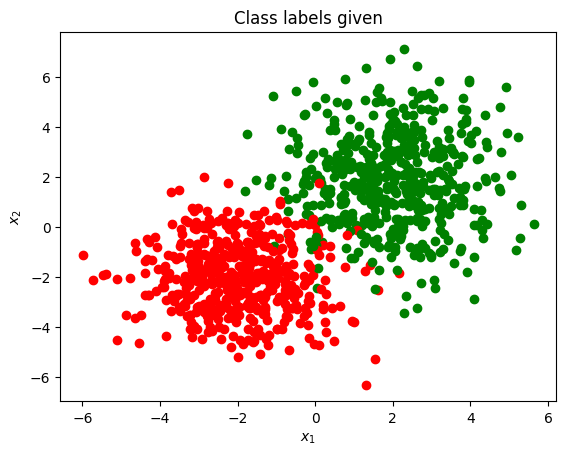

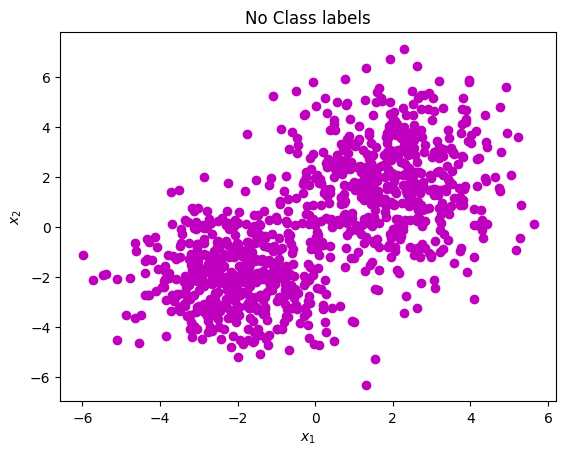

In [3]:
# Training data - two randomly-generated Gaussian-distributed clouds of points in 2d space
np.random.seed(0)
# Number of points
N = 1000
# Labels for each cluster
y = np.random.randint(low=0, high=2, size = N)
c = np.array(["r","g"])
# Mean of each cluster
means = np.array([[-2, 2], [-2, 2],])
# Covariance (in X and Y direction) of each cluster
covariances = np.random.random_sample((2, 2)) + 1
# Dimensions of each point
X = np.vstack([np.random.randn(N)*covariances[0, y] + means[0, y],
               np.random.randn(N)*covariances[1, y] + means[1, y]])

for k in range(X.shape[1]):
    plt.plot(X[0,k],X[1,k],c[y[k]]+"o")
    
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Class labels given")
plt.show()

for k in range(X.shape[1]):
    plt.plot(X[0,k],X[1,k],"m"+"o")
    
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("No Class labels")
plt.show()

# Plot the data

## K-means

**Please write a generic python function (in a separate package) which implements a generic version of the K-means algorithm. Your function should take as input a $d$-dimensional data set and the number of clusters into which you wish to group your data set. Return the means of your K-clusters and the assigned labels of your dataset (use 1-of-K coding to represent your labels). Initialize your means with two random samples.**

In [4]:
X.shape, X

((2, 1000),
 array([[-1.2566337 ,  1.69425932,  1.51472589, ..., -2.01075807,
          1.28242532, -0.63330216],
        [-1.36852293,  1.11203788,  2.27076249, ..., -2.45973637,
          1.55144031, -0.69209094]]))

In [5]:
from MyModels import Kmeans
Km_model = Kmeans(n_clusters=2)
Km_model.fit(X, max_iter=1000)


Convergence at iteration: 6 (Shift: 0.000000)


In [6]:
Km_model.predict(np.array([[0],[0]]))

array([1], dtype=int64)

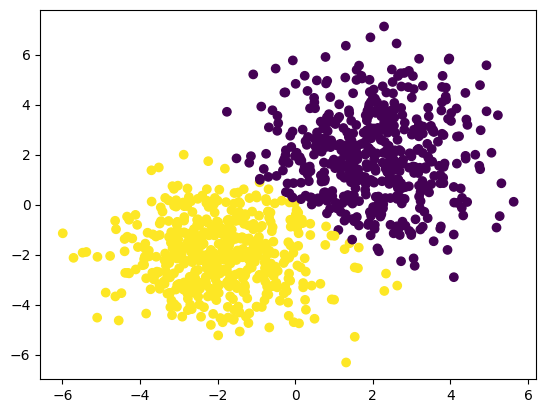

In [7]:
predicted = Km_model.predict(X)
plt.scatter(X[0,:], X[1,:], c = predicted)
plt.show()

In [8]:
""" use this to extract the means"""
Km_model.cluster_centers_[:,0]


array([2.0212828 , 1.99647112])

In [9]:
from IPython.display import HTML
from IPython.display import display
from IPython.display import Image

**Use your newly created function to assign labels to the random dataset we generated above. Plot the data and their newly assigned labels. Also plot the mean of the two clusters. Your generated plot should resemble the following:**

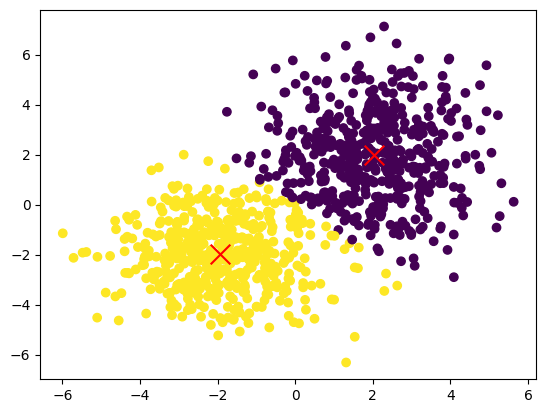

In [10]:
# Plot the centroids
predicted = Km_model.predict(X)
plt.scatter(X[0,:], X[1,:], c = predicted)
plt.scatter(Km_model.cluster_centers_[ 0], Km_model.cluster_centers_[ 1], 
            c='red', marker='x', s=200, label='Centroids')
plt.show()

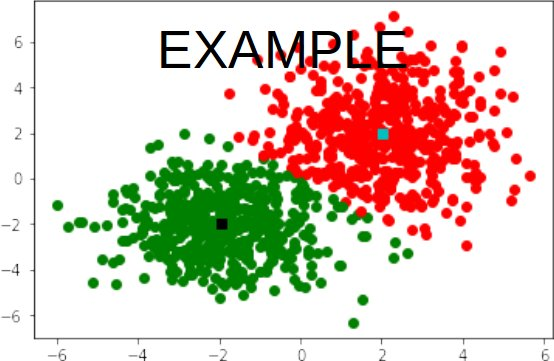

In [11]:
display(Image(filename='./kmeans.jpg'))

$x_1$ is on the $x$-axis and $x_2$ is on the $y$-axis.

# Perform K-means on an image

In [12]:
from skimage import io  # for loading an image from a file.
from sklearn.datasets import load_sample_image # imports available image from sklean dataset

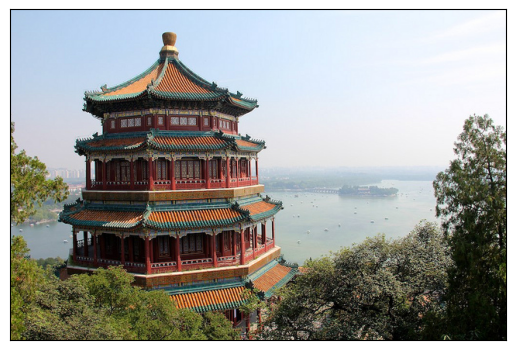

In [13]:
china = load_sample_image("china.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(china);

In [14]:
# Reshape the image
china.shape

(427, 640, 3)

In [15]:
data = china / 255.0 # use 0...1 scale
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

# Visualise possible colors from the image, using a k-means clustering across the pixel space


In [16]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data
    
    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

 The  MiniBatchKmeans is a variant of the KMeans algorithm which uses mini-batches to reduce the computation time, 
instead of using the full dataset at each iteration while still attempting to optimize the same objective function. 
 Mini-batches are subsets of the input data, randomly sampled in each training iteration. 
This increases the speed of the algorithm by a factor of 3–4 typically. Especially important, it makes it possible to cluster huge datasets that do not fit in memory.

Color Quantization is the process of reducing the number of colors in an image while keeping the visual appearance of the image intact. 
This is a useful image compression technique that is quite useful for devices that can show a limited number of colors due to memory restriction.

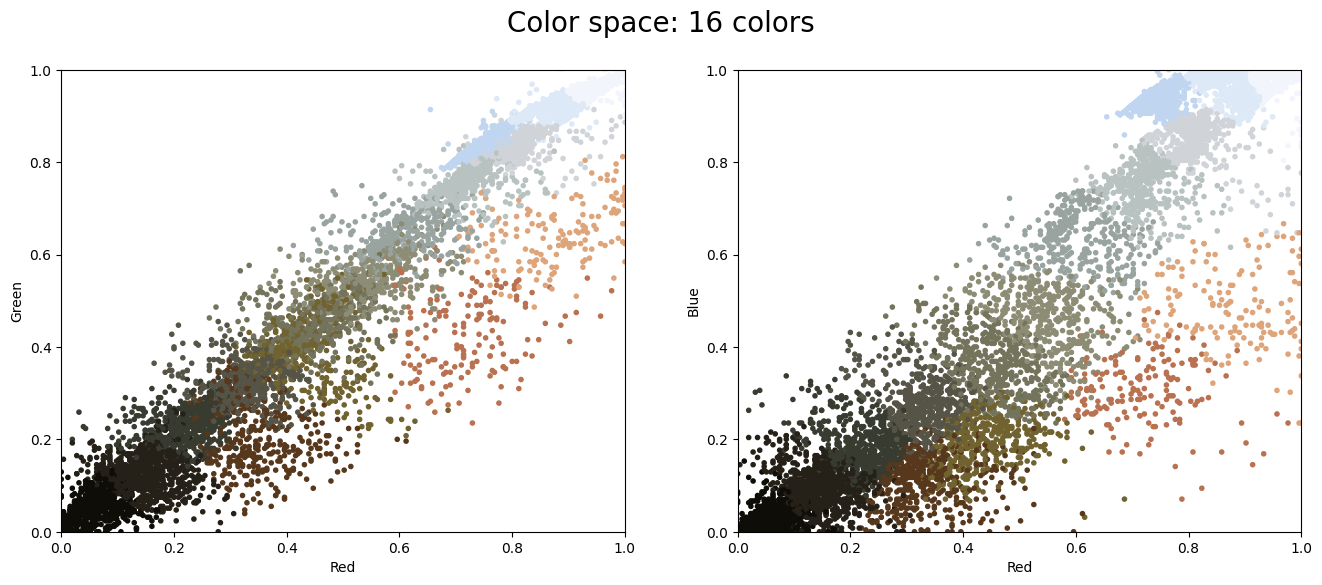

In [17]:
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Color space: 16 colors")

In [18]:
from ipywidgets import interact, interactive, fixed, interact_manual, IntSlider # for interactive slider

**Please create a widget function using the ipywidgets library of python that is already imported above and appy it to the image (china) above. Your function should take input K (the number of clusters) range slider. Hint: Read the documentation on ipywidgets. Reproducing the image using only 3 colors gives something like the following image.** 

**How many clusters do you need for a perfect reproduction?**

In [19]:
def quantize_image(k):
    # 1. Initialize and fit
    # MiniBatchKMeans is much faster for large images
    model = MiniBatchKMeans(n_clusters=k, batch_size=1024, n_init=3)
    model.fit(data) 
    
    # 2. Reconstruct using fancy indexing
    # This maps each pixel index to its center's RGB values
    quantized_dn = model.cluster_centers_[model.labels_]
    
    # 3. Reshape back to original dimensions
    quantized_img = quantized_dn.reshape(427, 640, 3)
    
    # 4. Plotting
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(china)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"MiniBatch K-Means (k={k})")
    plt.imshow(quantized_img)
    plt.axis('off')
    plt.show()

# 2. Create the widget interface
interact(quantize_image, k=IntSlider(min=2, max=640, step=2, value=8));

interactive(children=(IntSlider(value=8, description='k', max=640, min=2, step=2), Output()), _dom_classes=('w…

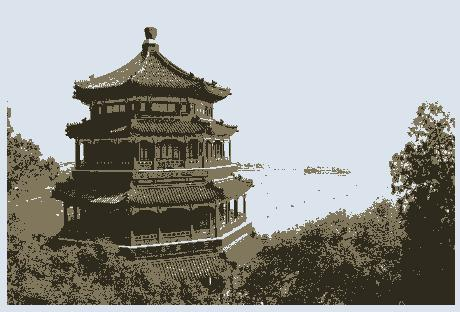

In [20]:
display(Image(filename='./Compressed.jpg'))

## GMM

**Please write a generic python function (in a separate package) which implements a generic version of the Gaussian Mixture Models algorithm. Your function should take as input a $d$-dimensional data set and the number of clusters into which you wish to group your data set. Return the number of members, the means and covariances of your K-clusters. Also return the responsibilites of your observations (of every sample in your dataset). Use your K-means function to intialize your GMM.**

**Use your newly created function to cluster the generated data set at the start of the K-Means section. Plot the 95% confidence
interval of your data and use the responsibility of each data point to set the color of each sample.
Your generated plot should resemble the following:**

In [21]:
from MyModels import GMM
import numpy as np
modelgmm = GMM(n_clusters=2)
modelgmm.fit(X)

Convergence at iteration: 4 (Shift: 0.000000)
GMM Converged at iteration 24


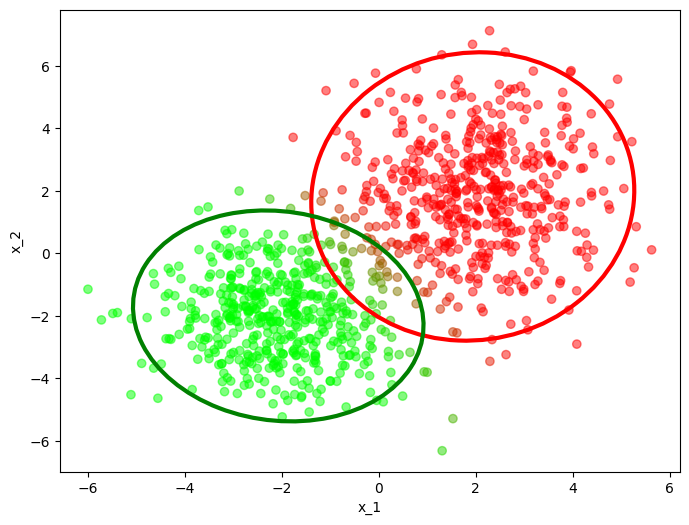

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Assuming your model is already trained:
# modelgmm = GMM(n_clusters=2)
# modelgmm.fit(X)

fig, ax = plt.subplots(figsize=(8, 6))

# ==========================================
# 1. Color the Points using Responsibilities
# ==========================================
# We create an RGBA color matrix (N points, 4 channels: Red, Green, Blue, Alpha)
N_points = modelgmm.N
colors = np.zeros((N_points, 4))

# Set the Red channel to Cluster 0's responsibility
colors[:, 0] = modelgmm.responsibilities_[:, 0] 
# Set the Green channel to Cluster 1's responsibility
colors[:, 1] = modelgmm.responsibilities_[:, 1] 
# Leave Blue as 0, and set Alpha (transparency) to 0.5 to match the image
colors[:, 3] = 0.5 

# Plot the scatter points (assuming X is shape (d, N))
ax.scatter(modelgmm.Data[0, :], modelgmm.Data[1, :], c=colors, marker='o')


# ==========================================
# 2. Draw the 95% Confidence Ellipses
# ==========================================
# The chi-square value for a 95% confidence interval with 2 degrees of freedom is ~5.991
chi2_val = 5.991
cluster_colors = ['red', 'green']

for j in range(modelgmm.n_clusters):
    # Get the mean and covariance for this specific cluster
    mean = modelgmm.means[:, j]
    cov = modelgmm.covariances[j]
    
    # Calculate eigenvalues and eigenvectors to find the ellipse's orientation and stretch
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # Calculate the width and height of the ellipse
    width, height = 2 * np.sqrt(eigenvalues * chi2_val)
    
    # Calculate the rotation angle of the ellipse in degrees
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    
    # Create the Ellipse patch
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=cluster_colors[j], facecolor='none', linewidth=3)
    
    # Add it to the plot
    ax.add_patch(ellipse)

# Formatting to match the screenshot
ax.set_xlabel('x_1')
ax.set_ylabel('x_2')
plt.show()

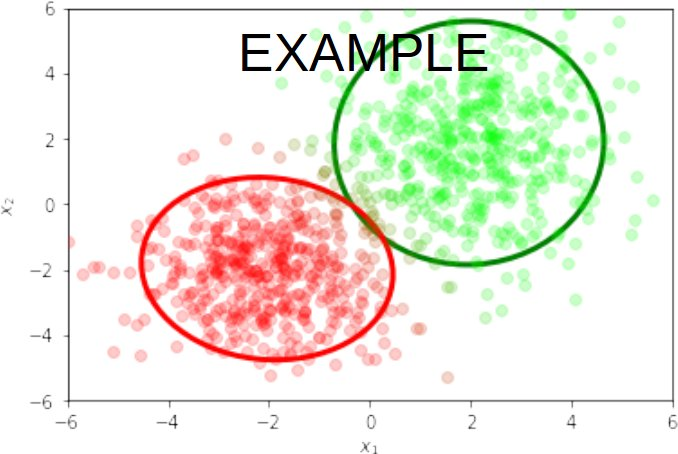

In [22]:
display(Image(filename='./gmm.jpg'))

# Clustering of digits data using GMM

For the next problem you will use GMM (scikit-learn version) to cluster the digits data in the scikit-learn library. 

## Load the digit datasets

The datasets are loaded into a dictionary.

In [23]:
# Import `datasets` from `sklearn`
from sklearn import datasets

# Load in the `digits` data
digits = datasets.load_digits()
print(digits.keys())

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [24]:
# Find the number of unique labels
number_digits = len(np.unique(digits.target))

print (number_digits)

10


In [25]:
digits.images.shape

(1797, 8, 8)

## Inspect the different digit  images

In [26]:
import matplotlib.cm as cm # helps you work with grayscale images

In [27]:
def show_digits(k=0):
    """
    Show the digits in the training set
    """
    
    plt.imshow(digits.images[k], cmap=cm.binary)   
    
    plt.show()
    
w_show_digits = interact(show_digits, k =(0, 1796)) 


interactive(children=(IntSlider(value=0, description='k', max=1796), Output()), _dom_classes=('widget-interact…


**Next, fit the data to a 10 component GMM model, using the scikit-learn package.**

**Once you have built the GMM model, extract the means as well as the covariances of the 10 GMM components. Display the means to get something like the  image below.**

In [28]:
from sklearn.mixture import GaussianMixture

# 1. Reshape from (1797, 8, 8) to (1797, 64)
# The -1 tells NumPy to calculate the remaining dimension (8 * 8 = 64) automatically
# flattened_digits = digits.images.reshape(digits.images.shape[0], -1)

# # 2. Transpose to get your expected (d, N) shape: (64, 1797)
# X = flattened_digits.T

# print(X.shape) # This will output (64, 1797)


# 1. Initialize and fit the Scikit-Learn GMM
# We use n_components=10 because there are 10 digits (0-9)


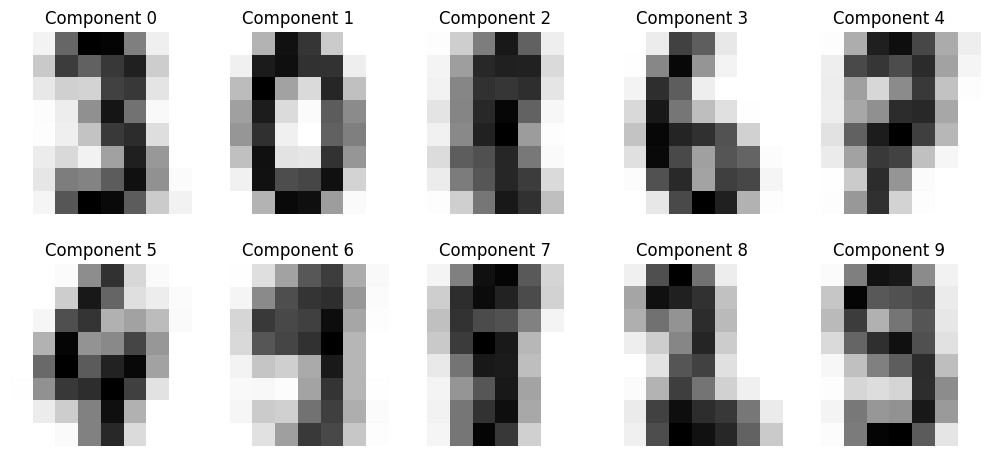

In [29]:
data = digits.data

np.random.seed(1)
gmm = GaussianMixture(n_components=10)

# Pass in the (1797, 64) shaped data!
gmm.fit(data) 


extracted_means = gmm.means_
extracted_covariances = gmm.covariances_

# 3. Display the means to see what the GMM "thinks" a digit looks like
# We set up a 2x5 grid of subplots to hold the 10 images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flatten()):
    # Reshape the 64-dimensional mean vector back into an 8x8 grid for plotting
    mean_image = extracted_means[i].reshape(8, 8)
    
    # Plot the image (using a grayscale colormap)
    ax.imshow(mean_image, cmap='binary')
    ax.set_title(f"Component {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Insert GMM code

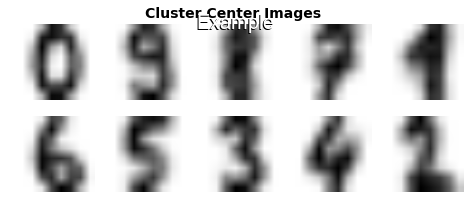

In [30]:
display(Image(filename='./wm_GMM.png'))

## Generate samples

**Use the means and covariances of the different components and draw a sample from each component. Display the samples in an image.**

*Hint*: Read the documentation of scipy.stats.multivariate_normal

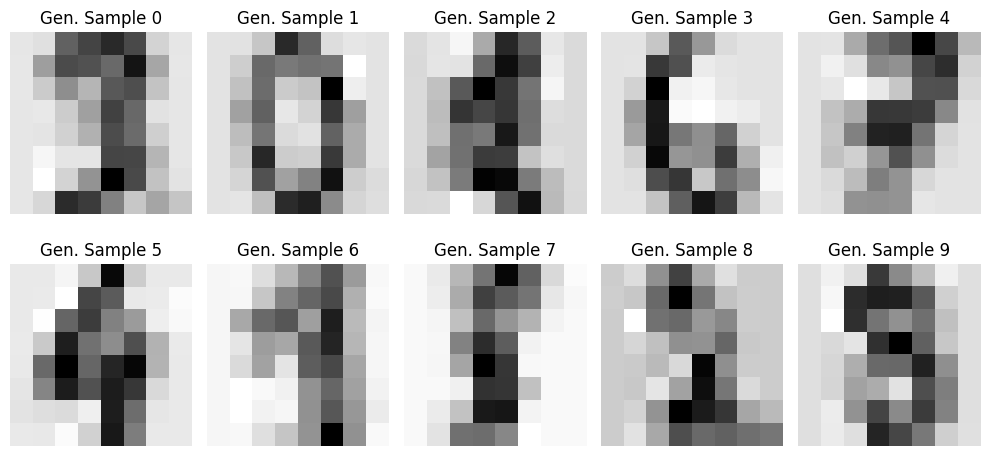

In [31]:
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Set up a 2x5 grid for our 10 generated images
fig2, axes2 = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes2.flatten()):
    # 1. Grab the mean and covariance for the current component
    mean_i = gmm.means_[i]
    cov_i = gmm.covariances_[i]
    
    # 2. Draw a single random sample from this specific Gaussian
    # rvs() returns a new 64-dimensional vector based on the distribution
    generated_sample = multivariate_normal.rvs(mean=mean_i, cov=cov_i)
    
    # 3. Reshape the 64-dimensional vector back into an 8x8 grid
    sample_image = generated_sample.reshape(8, 8)
    
    # 4. Plot the generated image
    ax.imshow(sample_image, cmap='binary')
    ax.set_title(f"Gen. Sample {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

**Now can you try out the color quantization and digit analyses with your newly created implementations of k-means and GMM respectively and see if you get the same outputs.**

Convergence at iteration: 24 (Shift: 0.000000)
GMM Converged at iteration 35


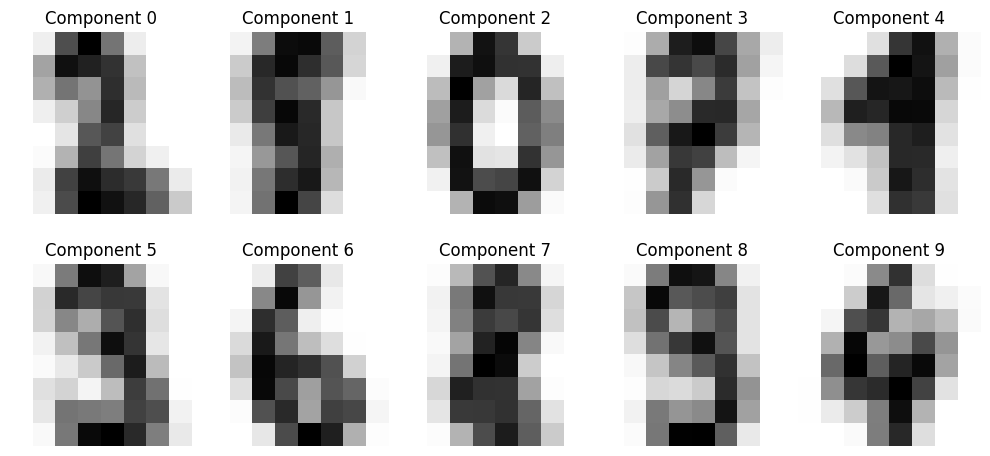

In [32]:
from MyModels import GMM as gmmine
data = digits.data

np.random.seed(1)
gmm2 = gmmine(n_clusters=10)

gmm2.fit(data.T) 

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

extracted_means2 = gmm2.means
extracted_covariances2 = gmm2.covariances



for i, ax in enumerate(axes.flatten()):
    # Reshape the 64-dimensional mean vector back into an 8x8 grid for plotting
    mean_image = extracted_means2[:,i].reshape(8, 8)
    
    # Plot the image (using a grayscale colormap)
    ax.imshow(mean_image, cmap='binary')
    ax.set_title(f"Component {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Insert GMM code

# ====================================================================================================================

In [33]:
from MyModels import Kmeans
import numpy as np
model1 = Kmeans(n_clusters=3)
data = np.array([[3, 5, 8, 16, 22, 31, 36, 43, 50, 59, 67, 73, 84, 96, 103, 111, 126, 141, 145, 160]])
model1.fit(data, initial_centers=np.array([[13,39,69]]))
model1.cluster_centers_

Convergence at iteration: 6 (Shift: 0.000000)


array([[ 17,  62, 126]])

### Procedure: Calculating a K-Means Decision Boundary (2D)

**Problem Statement:**
Given a $K$-means model with $K=2$ in a 2-dimensional space ($x_1$, $x_2$), find the linear decision boundary $x_2 = mx_1 + c$ separating the regions of two cluster means. 
* **Mean A:** $(8.7, 2.6)$
* **Mean B:** $(4.7, 0.5)$

**Concept:** The decision boundary between two clusters in K-means is the set of all points equidistant from both cluster centers. Geometrically, this forms the **perpendicular bisector** of the line segment connecting the two means.

#### Step 1: Calculate the Midpoint
The boundary must pass exactly halfway between the two cluster means. Find the midpoint $M(x_{1M}, x_{2M})$ by averaging their coordinates:

$$M = \left( \frac{x_{1A} + x_{1B}}{2}, \frac{x_{2A} + x_{2B}}{2} \right)$$
$$M = \left( \frac{8.7 + 4.7}{2}, \frac{2.6 + 0.5}{2} \right)$$
$$M = (6.7, 1.55)$$

#### Step 2: Find the Slope Between the Means
Calculate the slope ($m_{AB}$) of the imaginary line connecting point A to point B.

$$m_{AB} = \frac{x_{2A} - x_{2B}}{x_{1A} - x_{1B}}$$
$$m_{AB} = \frac{2.6 - 0.5}{8.7 - 4.7}$$
$$m_{AB} = \frac{2.1}{4.0} = 0.525$$

#### Step 3: Determine the Boundary's Slope
Because the decision boundary is perpendicular to the line connecting the means, its slope ($m$) is the **negative reciprocal** of $m_{AB}$.

$$m = -\frac{1}{m_{AB}}$$
$$m = -\frac{1}{0.525}$$
$$m = -\frac{40}{21} \approx -1.90476$$

#### Step 4: Solve for the Intercept ($c$)
The decision boundary follows the linear equation $x_2 = m x_1 + c$. Substitute the boundary's slope ($m$) and the coordinates of the midpoint ($M$) into the equation to solve for the intercept $c$.

$$1.55 = \left(-\frac{40}{21}\right)(6.7) + c$$
$$1.55 = -12.76190... + c$$
$$c = 1.55 + 12.76190...$$
$$c = 14.31190$$

#### Final Result
The exact value of $c$, accurate to 5 decimal places, is **$14.31190$**. 
The full equation for the decision boundary is: 

$$x_2 = -1.90476x_1 + 14.31190$$

In [56]:
import numpy as np

# 1. Define the means as numpy vectors
A = np.array([5.0, 7.2])
B = np.array([2.5, 1.9])

# 2. Vectorized difference (A - B gives us [dx, dy])
diff = A - B  

# diff[0] is delta_x, diff[1] is delta_y
# 3. The perpendicular slope is -dx / dy
m = -diff[0] / diff[1]

print(f"The value of m is: {m:.5f}")

The value of m is: -0.47170


In [34]:
import numpy as np
from MyModels import GMM as obgmm
X = np.array([[3.1,3.2],[2.4,5.7]])
u = np.array([1,1])

In [35]:
import numpy as np

def update_covariance_and_get_element(X, u, gamma, row_idx, col_idx):
    """
    Computes the covariance matrix update for a GMM and returns a specific element.
    
    Parameters:
    X : numpy array of shape (d, N) representing the data matrix.
    u : numpy array representing the mean vector for the component.
    gamma : numpy array of shape (N,) representing responsibilities for this component.
    row_idx : integer, 1-based row index of the element to extract.
    col_idx : integer, 1-based column index of the element to extract.
    """
    # 1. Get dimensions
    d, N = X.shape
    
    # 2. Calculate N_j (Sum of responsibilities)
    N_j = np.sum(gamma)
    
    # 3. Initialize the covariance matrix (d x d) with zeros
    Sigma_j = np.zeros((d, d))
    
    # Ensure the mean is a column vector of shape (d, 1) for broadcasting/math
    u_col = u.reshape(d, 1)
    
    # 4. Loop through each data point to calculate the sum
    for n in range(N):
        # Extract the n-th data point as a column vector (d, 1)
        x_n = X[:, n].reshape(d, 1)
        
        # Calculate (x_n - u_j)
        diff = x_n - u_col
        
        # Calculate the outer product: (x_n - u_j)(x_n - u_j)^T
        outer_product = diff @ diff.T
        
        # Multiply by responsibility gamma(z_nj) and add to the running sum
        Sigma_j += gamma[n] * outer_product
        
    # 5. Divide the total sum by N_j to get the final Covariance Matrix
    Sigma_j = Sigma_j / N_j
    
    # 6. Extract the requested element 
    # (Subtracting 1 because mathematical notation [1,2] is [0,1] in Python's 0-based indexing)
    target_element = Sigma_j[row_idx - 1, col_idx - 1]
    
    return target_element, Sigma_j

# ==========================================
# Applying the givens from your specific problem
# ==========================================

X_data = np.array([[3, 4], 
                   [1, 6]])

u_mean = np.array([1, 1])

# Responsibilities for gamma(z_11) and gamma(z_21)
gamma_probs = np.array([0.4, 0.6])

# Calculate and retrieve the [Sigma_1]_12 element (Row 1, Column 2)
element_val, full_matrix = update_covariance_and_get_element(X, u, gamma_probs, row_idx=1, col_idx=2)

print("Full Covariance Matrix Σ_1:")
print(full_matrix)
print("\nRequested Element [Σ_1]_12 (Accurate to 5 decimal places):")
print(f"{element_val:.5f}")

Full Covariance Matrix Σ_1:
[[ 4.668  7.38 ]
 [ 7.38  14.038]]

Requested Element [Σ_1]_12 (Accurate to 5 decimal places):
7.38000


In [36]:
import numpy as np


In [37]:
X = np.array([[4.41,2.94],[2.94,1.96]])*0.4
Y = np.array([[4.84,10.34],[10.34,22.09]])*0.6

In [38]:
X+Y

array([[ 4.668,  7.38 ],
       [ 7.38 , 14.038]])

In [39]:
import math

def estimate_gamma(p, u, sigma_sq, x, j):
    """
    Computes responsibilities. Assumes one-dimensional data and a two component mixture model.
    
    @param p: mixture coefficients. 1D list of length 2.
    @param u: class means. 1D list of length 2.
    @param sigma_sq: class variances. 1D list of length 2.
    @param x: data points. 1D list of floats.
    @param j: component index (0 or 1) to calculate responsibility for.
    """
    responsibilities = []
    
    for val in x:
        # Calculate Gaussian PDF for Component 0
        coeff_0 = 1.0 / math.sqrt(2 * math.pi * sigma_sq[0])
        exp_0 = math.exp(-((val - u[0]) ** 2) / (2 * sigma_sq[0]))
        pdf_0 = coeff_0 * exp_0
        
        # Calculate Gaussian PDF for Component 1
        coeff_1 = 1.0 / math.sqrt(2 * math.pi * sigma_sq[1])
        exp_1 = math.exp(-((val - u[1]) ** 2) / (2 * sigma_sq[1]))
        pdf_1 = coeff_1 * exp_1
        
        # Apply the mixing coefficients (the numerators)
        weight_0 = p[0] * pdf_0
        weight_1 = p[1] * pdf_1
        
        # Sum them up (the denominator)
        denominator = weight_0 + weight_1
        
        # Calculate responsibility for the requested component 'j'
        if j == 0:
            gamma = weight_0 / denominator
        elif j == 1:
            gamma = weight_1 / denominator
        else:
            raise ValueError("j must be 0 or 1 for a two-component model.")
            
        responsibilities.append(round(gamma,4))
        
    return responsibilities

In [40]:
estimate_gamma([0.4,0.6],[0,1],[1,1],[-1,1,1.2],0)

[0.7492, 0.2879, 0.2487]

In [41]:
import math

def est(p, u, sigma_sq, x, j):
    responsibilities = []
    for val in x:
        norm_0 = 1/math.sqrt(2*math.pi*sigma_sq[j]) * math.exp(-0.5*((val-u[j])/math.sqrt(sigma_sq[j]))**2)
        denom = 0
        for i in range(len(p)):
            denom += p[i]*1/math.sqrt(2*math.pi*sigma_sq[i]) * math.exp(-0.5*((val-u[i])/math.sqrt(sigma_sq[i]))**2)
        num0 = norm_0*p[j]
        responsibilities.append(round(num0/denom,4))
    return responsibilities
        
             
        

In [42]:
est([0.4,0.6],[0,1],[1,1],[-1,1,1.2],1)

[0.2508, 0.7121, 0.7513]

# How to extract my code from my classes for individual steps

In [43]:
from MyModels import GMM
# 1. Instantiate your class
my_gmm = GMM(n_clusters=2)

# 2. MANUALLY INJECT the data and dimensions (Skipping the fit method)
# Reshape the 1D array into (1, 5)
my_gmm.Data = np.array([[179, 165, 175, 185, 158]]) 
my_gmm.d = 1
my_gmm.N = 5

# 3. MANUALLY INJECT the professor's initial parameters
# Means shape must be (d, k) -> (1, 2)
my_gmm.means = np.array([[175.0, 165.0]]) 

# Pi coefficients shape -> (2,)
my_gmm.coeff_ = np.array([0.6, 0.4])

# Covariance shape must be (k, d, d) -> (2, 1, 1). 
# We MUST square the professor's 10 to get a variance of 100!
my_gmm.covariances = np.array([ [[100.0]], [[100.0]] ])

# 4. MANUALLY run exactly one iteration
my_gmm._e_step(my_gmm.Data)
my_gmm._m_step(my_gmm.Data)

# 5. Extract the results (and square root the covariance back to standard dev)
print(f"μ_1: {my_gmm.means[0, 0]:.0f}")
print(f"μ_2: {my_gmm.means[0, 1]:.0f}")
print(f"Σ_1: {np.sqrt(my_gmm.covariances[0, 0, 0]):.1f}")
print(f"Σ_2: {np.sqrt(my_gmm.covariances[1, 0, 0]):.1f}")
print(f"π_1: {my_gmm.coeff_[0]:.2f}")

μ_1: 176
μ_2: 167
Σ_1: 8.6
Σ_2: 9.0
π_1: 0.63


In [44]:
np.round(my_gmm.means)

array([[176., 167.]])

In [45]:
import numpy as np

X = np.array([[ 0.70849269, -0.61451051, -4.13847659, -3.58846251],[-0.81884773,  0.34072422, 0.37639262,  0.10408057]])

p = np.array([0.3,0.7]) # proportions
u = np.array([[1.2, 0.4], [-4.4, 1.0]]) # means
s = np.array([[0.8, -0.4],[-0.4, 1.0],[1.2, -0.8],[-0.8, 1.0]]).reshape(2,2,2) # covariance matrices
s

array([[[ 0.8, -0.4],
        [-0.4,  1. ]],

       [[ 1.2, -0.8],
        [-0.8,  1. ]]])

In [46]:
m = GMM(n_clusters = 2, max_iter=1)
m.Data = X
m.covariances = s
m.means = u.T

m.coeff_ = p
m.d, m.N = X.shape
m._e_step(X)
m._m_step(X)


In [47]:
m.coeff_

array([0.49945852, 0.50054148])

In [48]:
m.responsibilities_

array([[9.99985850e-01, 1.41504918e-05],
       [9.97848217e-01, 2.15178270e-03],
       [1.01239220e-10, 1.00000000e+00],
       [3.91429451e-09, 9.99999996e-01]])